# 03 — Evaluation: метрики и figures для ВКР (v4 noleak edition)

Источник чисел — `docs/thesis/data_methodology.md` §14. Финальная конфигурация:
- модели `*_v4_mpnet_tfidf_noleak` (`scripts/build_noleak_artifacts.py`);
- gold: LLM-consensus (3257 cells, primary) + HUMAN/Opus (n=566 cascade-valid, conservative bound);
- router: `category_router_v5`;
- эталонные скрипты:
  - `python -m src.eval.metric_table` → `datasets/processed/v4_metric_table_v2.json`
  - `python -m src.eval.end_to_end`    → `datasets/processed/v4_e2e_router_eval.json`

Запускать рекомендуется на VM (`/home/miafrolov/Desktop/diploma`), где доступен `off_work/{cat}_off_full.parquet`.
На локальной машине, если артефактов нет, ноутбук всё равно выведет числа методички §14 (placeholder mode) и сохранит 3 PNG.

**Регенерирует 3 figures в `images/`:** `tier_breakdown.png` (per-attribute macro-F1 bar), `cost_quality_scatter.png`, `layer_contribution.png`.

**Дефолт:** light, без heavy шагов. Включай `HEAVY['regenerate_metrics']=True` чтобы пересчитать json'ы через subprocess.

In [1]:
%env OMP_NUM_THREADS=1

import sys
from pathlib import Path

assert sys.version_info[:2] in [(3, 12), (3, 14)]

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED = PROJECT_ROOT / 'datasets' / 'processed'
MODELS = PROJECT_ROOT / 'models'
IMAGES = PROJECT_ROOT / 'images'
IMAGES.mkdir(exist_ok=True)

CATEGORIES_LONG = ['pasta', 'chocolate', 'cheeses']

# Heavy steps:
#  cascade_predict      — legacy pre-v4 pipeline (cascade_preds_*_v2_gold_hybrid_v3_fixed.parquet)
#  regenerate_metrics   — `python -m src.eval.metric_table` + `src.eval.end_to_end`
#                         требует доступ к off_full parquet (обычно VM)
HEAVY = {
    'cascade_predict':    False,
    'regenerate_metrics': False,
}

import matplotlib
matplotlib.use('Agg')  # детерминированный backend
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)
plt.rcParams['savefig.dpi'] = 150

import pandas as pd
import json

SAVEFIG_KW = dict(dpi=150, bbox_inches='tight',
                  metadata={'Date': None, 'Software': None, 'Creator': None})

print(f'PROJECT_ROOT = {PROJECT_ROOT}')

env: OMP_NUM_THREADS=1


PROJECT_ROOT = /Users/miafrolov/Desktop/stuff/ai_attributes


In [2]:
import seaborn as sns
import matplotlib.ticker as mticker

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['legend.fontsize'] = 10

PALETTE = sns.color_palette('viridis', 8)
TAB10 = sns.color_palette('tab10', 10)
print(f'PROCESSED exists: {PROCESSED.is_dir()}')
print(f'MODELS exists:    {MODELS.is_dir()}')
print(f'IMAGES exists:    {IMAGES.is_dir()}')

PROCESSED exists: True
MODELS exists:    True
IMAGES exists:    True


## 0. Heavy regenerate (опционально)

Если `HEAVY['regenerate_metrics']=True`, ноутбук запустит `src.eval.metric_table` и `src.eval.end_to_end` через subprocess. Требуется доступ к `off_work/{cat}_off_full.parquet` (`/home/miafrolov/off_work/` на VM) и `models/{cat}_v4_mpnet_tfidf_noleak_*`.

Output: `datasets/processed/v4_metric_table_v2.json` и `datasets/processed/v4_e2e_router_eval.json`.

Legacy шаг `cascade_predict` оставлен только для секций 6+ (Bayes validator, ECE и пр.).

In [3]:
import subprocess

if HEAVY['regenerate_metrics']:
    for mod in ['src.eval.metric_table', 'src.eval.end_to_end']:
        try:
            print(f'>>> python -m {mod}')
            r = subprocess.run(['python', '-m', mod], cwd=PROJECT_ROOT,
                               check=False, timeout=1800,
                               capture_output=True, text=True)
            print(r.stdout[-1500:])
            if r.returncode != 0:
                print('STDERR:', r.stderr[-800:])
        except Exception as e:
            print(f'{mod} skipped: {e!r}')

if HEAVY['cascade_predict']:
    for cat in CATEGORIES_LONG:
        out = PROCESSED / f'cascade_preds_{cat}_v2_gold_hybrid_v3_fixed.parquet'
        if not out.exists():
            try:
                subprocess.run(
                    ['python', '-m', 'src.eval.cascade_predict', '--category', cat],
                    cwd=PROJECT_ROOT, check=False, timeout=600,
                )
            except Exception as e:
                print(f'{cat} cascade_predict skipped: {e}')
        print(f'{cat}: {"OK" if out.exists() else "missing"} {out.name}')

metric_table_path = PROCESSED / 'v4_metric_table_v2.json'
e2e_router_path = PROCESSED / 'v4_e2e_router_eval.json'
print()
print(f'v4_metric_table_v2.json:  {"OK" if metric_table_path.exists() else "MISSING"}')
print(f'v4_e2e_router_eval.json:  {"OK" if e2e_router_path.exists() else "MISSING"}')
if not metric_table_path.exists() or not e2e_router_path.exists():
    print('Если артефактов нет — секции 1–4 будут использовать hard-coded числа из methodology §14.')
    print('Для регенерации: на VM HEAVY["regenerate_metrics"]=True ИЛИ ручной запуск:')
    print('  python -m src.eval.metric_table && python -m src.eval.end_to_end')


v4_metric_table_v2.json:  OK
v4_e2e_router_eval.json:  OK


## 1. Headline на LLM-consensus gold (n=3257) — primary

Источник: `src.eval.end_to_end` + `src.eval.metric_table` на `manual_gold_consensus.parquet` (3-LLM majority vote, n=3257 cells × {pasta, chocolate, cheeses}).

Целевые числа (methodology §14.1):
- Cascade-only micro: **94.8 %**, macro-F1 (cells-weighted) **0.899**;
- E2E (None=wrong, production-realistic): **91.1 %**, coverage **96.0 %**;
- Router accuracy (per code, n=570): **95.4 %**.

In [4]:
# Reference numbers from methodology §14.1 (extended consensus rerun 2026-05-27)
HEADLINE_CONSENSUS = {
    'n_cells':              16360,
    'cascade_only_micro':   0.955,
    'cascade_only_macro_f1_cells_weighted': 0.890,
    'cascade_only_macro_f1_attr_unweighted': 0.892,
    'e2e_acc_none_as_wrong': 0.930,
    'e2e_coverage':          0.973,
    'router_acc':            0.972,
    'router_n_codes':        570,
}

def _load_json(p):
    if not p.exists():
        return None
    with open(p, encoding='utf-8') as f:
        return json.load(f)

mt = _load_json(metric_table_path)
e2e = _load_json(e2e_router_path)

def _cells_weighted(attrs_dict, key):
    ns = [v['n'] for v in attrs_dict.values()]
    vals = [v[key] for v in attrs_dict.values()]
    return float(np.average(vals, weights=ns)), int(sum(ns))

if mt and 'LLM-consensus' in mt:
    attrs = mt['LLM-consensus']
    micro_w, n_total = _cells_weighted(attrs, 'micro_acc')
    macro_w, _ = _cells_weighted(attrs, 'macro_f1')
    print(f'[v4 metric_table] LLM-consensus: n_cells={n_total}, micro={micro_w*100:.1f}%, macro-F1={macro_w:.3f}')
else:
    print('WARNING: v4_metric_table_v2.json отсутствует — fallback на methodology §14.1')

if e2e and 'LLM-consensus' in e2e:
    r = e2e['LLM-consensus']
    print(f'[v4 end_to_end] LLM-consensus: cascade_only={r["cascade_only_acc"]*100:.1f}%, '
          f'E2E(None=wrong)={r["e2e_acc_none_as_wrong"]*100:.1f}%, '
          f'coverage={r["e2e_coverage"]*100:.1f}%, router={r["router_acc"]*100:.1f}%')
else:
    print('WARNING: v4_e2e_router_eval.json отсутствует — fallback на methodology §14.1')

print()
print('=' * 78)
print('Headline (LLM-consensus gold extended, n=16360) — methodology §14.1:')
print('=' * 78)
rows = pd.DataFrame([
    {'metric': 'Cascade-only micro-accuracy',           'value': f"{HEADLINE_CONSENSUS['cascade_only_micro']*100:.1f}%"},
    {'metric': 'Cascade-only macro-F1 (cells-weighted)', 'value': f"{HEADLINE_CONSENSUS['cascade_only_macro_f1_cells_weighted']:.3f}"},
    {'metric': 'Cascade-only macro-F1 (attr-unweighted)','value': f"{HEADLINE_CONSENSUS['cascade_only_macro_f1_attr_unweighted']:.3f}"},
    {'metric': 'Router accuracy (per code, n=570)',     'value': f"{HEADLINE_CONSENSUS['router_acc']*100:.1f}%"},
    {'metric': 'E2E coverage',                          'value': f"{HEADLINE_CONSENSUS['e2e_coverage']*100:.1f}%"},
    {'metric': 'E2E accuracy (None=wrong) — production', 'value': f"{HEADLINE_CONSENSUS['e2e_acc_none_as_wrong']*100:.1f}%"},
])
display(rows)

[v4 metric_table] LLM-consensus: n_cells=16360, micro=95.5%, macro-F1=0.890
[v4 end_to_end] LLM-consensus: cascade_only=95.5%, E2E(None=wrong)=93.0%, coverage=97.3%, router=97.2%

Headline (LLM-consensus gold extended, n=16360) — methodology §14.1:


,metric,value
0,Cascade-only micro-accuracy,95.5%
1,Cascade-only macro-F1 (cells-weighted),0.890
2,Cascade-only macro-F1 (attr-unweighted),0.892
3,"Router accuracy (per code, n=570)",97.2%
4,E2E coverage,97.3%
5,E2E accuracy (None=wrong) — production,93.0%


## 2. Conservative bound — HUMAN gold (Opus)

Источник: `manual_eval_per_product.parquet` (single labeler Opus, без IRR). Используется как нижняя оценка (conservative bound).

Числа читаются из `datasets/processed/v4_e2e_router_eval.json` (live из `src.eval.end_to_end`):
- Cascade-only: **91.3 %** на cascade-valid сегменте (n=566 ячеек, где cascade выдал не-None);
- E2E (None=wrong): **86.7 %** — счётается на том же сегменте, router-misroute = wrong;
- Router (n=107): **95.3 %**.

Семантика: `n_valid_cells=566` — это ячейки, на которых каскад вернул конкретный класс (rule_h ∪ ML ∪ rule_l). 122 ячейки Layer 4 LLM fallback из эталона уходят в LLM в production, поэтому исключены из cascade-only знаменателя. См. §14.2 methodology.

In [5]:
# 2. Conservative bound на HUMAN gold (Opus) — источник: src/eval/end_to_end.py.
# Hardcoded HEADLINE_HUMAN dict удалён по принципу «notebook = executable source of truth».
# Числа читаются из live v4_e2e_router_eval.json; при отсутствии — fallback с WARNING.
#
# Семантика: cascade_only_acc и e2e_acc_none_as_wrong считаются на сегменте
# cells, где cascade вернул не-None предсказание (`n_valid_cells`). Layer 4
# (LLM fallback) cells исключены — в production они отправляются в LLM.

CANONICAL_HUMAN_FALLBACK = {
    'n_cells':              566,
    'cascade_only_micro':   0.913,
    'cascade_only_macro_f1': 0.848,
    'e2e_acc_none_as_wrong': 0.867,
    'e2e_coverage':          0.951,
    'router_acc':            0.953,
    'router_n_codes':        107,
}

# Cells-weighted macro-F1 — пока только из metric_table_v2.json (VM-only артефакт)
if mt and 'HUMAN' in mt:
    attrs = mt['HUMAN']
    micro_w, n_total = _cells_weighted(attrs, 'micro_acc')
    macro_w, _ = _cells_weighted(attrs, 'macro_f1')
    print(f'[v4 metric_table] HUMAN: n_cells={n_total}, micro={micro_w*100:.1f}%, macro-F1={macro_w:.3f}')
else:
    print('WARNING: HUMAN секция в v4_metric_table_v2.json отсутствует — macro-F1 берётся из CANONICAL fallback.')

if e2e and 'HUMAN' in e2e:
    r = e2e['HUMAN']
    HEADLINE_HUMAN = {
        'n_cells':              int(r['n_valid_cells']),
        'cascade_only_micro':   float(r['cascade_only_acc']),
        'cascade_only_macro_f1': float(mt['HUMAN'].get('_cells_weighted_macro_f1', CANONICAL_HUMAN_FALLBACK['cascade_only_macro_f1'])) if mt and 'HUMAN' in mt and isinstance(mt['HUMAN'], dict) else CANONICAL_HUMAN_FALLBACK['cascade_only_macro_f1'],
        'e2e_acc_none_as_wrong': float(r['e2e_acc_none_as_wrong']),
        'e2e_coverage':          float(r['e2e_coverage']),
        'router_acc':            float(r['router_acc']),
        'router_n_codes':        CANONICAL_HUMAN_FALLBACK['router_n_codes'],
    }
    headline_src = 'v4_e2e_router_eval.json (live)'
    print(f'[v4 end_to_end] HUMAN: cascade_only={r["cascade_only_acc"]*100:.1f}%, '
          f'E2E(None=wrong)={r["e2e_acc_none_as_wrong"]*100:.1f}%, '
          f'coverage={r["e2e_coverage"]*100:.1f}%, router={r["router_acc"]*100:.1f}%, '
          f'n_valid_cells={r["n_valid_cells"]}')
else:
    HEADLINE_HUMAN = dict(CANONICAL_HUMAN_FALLBACK)
    headline_src = 'CANONICAL fallback (FALLBACK — run `python -m src.eval.end_to_end` on VM to refresh)'
    print('⚠️  WARNING: v4_e2e_router_eval.json не содержит HUMAN — используется CANONICAL fallback.')

print()
print('=' * 78)
print(f'Conservative bound (HUMAN gold, Opus, n={HEADLINE_HUMAN["n_cells"]} cascade-valid) — methodology §14.2:')
print(f'Источник: {headline_src}')
print('=' * 78)
rows = pd.DataFrame([
    {'metric': f'Cascade-only micro-accuracy (n={HEADLINE_HUMAN["n_cells"]})', 'value': f"{HEADLINE_HUMAN['cascade_only_micro']*100:.1f}%"},
    {'metric': 'Cascade-only macro-F1',        'value': f"{HEADLINE_HUMAN['cascade_only_macro_f1']:.3f}"},
    {'metric': f'Router accuracy (n={HEADLINE_HUMAN["router_n_codes"]})',      'value': f"{HEADLINE_HUMAN['router_acc']*100:.1f}%"},
    {'metric': 'E2E coverage',                 'value': f"{HEADLINE_HUMAN['e2e_coverage']*100:.1f}%"},
    {'metric': 'E2E accuracy (None=wrong)',    'value': f"{HEADLINE_HUMAN['e2e_acc_none_as_wrong']*100:.1f}%"},
])
display(rows)

[v4 metric_table] HUMAN: n_cells=566, micro=91.3%, macro-F1=0.843
[v4 end_to_end] HUMAN: cascade_only=91.3%, E2E(None=wrong)=86.7%, coverage=95.1%, router=95.3%, n_valid_cells=566

Conservative bound (HUMAN gold, Opus, n=566 cascade-valid) — methodology §14.2:
Источник: v4_e2e_router_eval.json (live)


,metric,value
0,Cascade-only micro-accuracy (n=566),91.3%
1,Cascade-only macro-F1,0.848
2,Router accuracy (n=107),95.3%
3,E2E coverage,95.1%
4,E2E accuracy (None=wrong),86.7%


## 3. Category router accuracy (Layer 0)

`category_router_v5` (XGBoost на MPNet embeddings) — pre-cascade Layer 0. Эталонные числа:
- LLM-consensus codes (n=570): **95.4 %**;
- HUMAN codes (n=107): **95.3 %**.

Источник: `src.eval.end_to_end` → `v4_e2e_router_eval.json`.

In [6]:
router_rows = pd.DataFrame([
    {'gold': 'LLM-consensus', 'n_codes': HEADLINE_CONSENSUS['router_n_codes'],
     'router_acc_%': HEADLINE_CONSENSUS['router_acc']*100},
    {'gold': 'HUMAN (Opus)',  'n_codes': HEADLINE_HUMAN['router_n_codes'],
     'router_acc_%': HEADLINE_HUMAN['router_acc']*100},
])
if e2e:
    for gl, r in e2e.items():
        router_rows.loc[router_rows.gold.str.startswith(gl), 'router_acc_%'] = float(r['router_acc']) * 100
display(router_rows.round(2))

,gold,n_codes,router_acc_%
0,LLM-consensus,570,97.16
1,HUMAN (Opus),107,95.33


## 4. Per-attribute macro-F1 (LLM-consensus gold, 20 атрибутов)

Methodology §14.3 — 20 строк: 7 pasta + 6 chocolate + 7 cheeses. Источник:
`v4_metric_table_v2.json` (LLM-consensus) → нотбук-cell записывает
`report/contents/tables/per_attr_consensus.tex`, который подключается в
§3.3.2.3 ВКР через `\input`. n_per_attr ∈ [267; 1225] на extended consensus
rerun (2026-05-27, n_total=16360 cascade-valid).

**Регенерирует `images/tier_breakdown.png`** — bar chart per-attribute macro-F1 (адаптирован под v4 schema).


In [ ]:
# Methodology §14.3 — per-attribute table (LLM-consensus, extended rerun n=16360)
# Source: datasets/processed/v4_metric_table_v2.json (LLM-consensus key).
# Pre-extended-rerun PER_ATTR_FALLBACK (stale n=139 values) удалён —
# нотбук читает только live JSON. При отсутствии — WARN и skip.

PER_ATTR_ORDER = [
    # (category, attr) — порядок строк в таблице (7 pasta + 6 chocolate + 7 cheeses)
    ('pasta',     'grain_type'),
    ('pasta',     'pasta_shape'),
    ('pasta',     'is_filled'),
    ('pasta',     'is_gluten_free'),
    ('pasta',     'is_organic'),
    ('pasta',     'is_vegan'),
    ('pasta',     'cuisine_origin'),
    ('chocolate', 'chocolate_type'),
    ('chocolate', 'is_filled'),
    ('chocolate', 'chocolate_extra'),
    ('chocolate', 'contains_nuts'),
    ('chocolate', 'is_organic'),
    ('chocolate', 'flavor_profile'),
    ('cheeses',   'milk_source'),
    ('cheeses',   'texture'),
    ('cheeses',   'country_of_origin'),
    ('cheeses',   'aging'),
    ('cheeses',   'is_pdo'),
    ('cheeses',   'is_organic'),
    ('cheeses',   'is_ultra_processed'),
]

if not (mt and 'LLM-consensus' in mt):
    print('⚠️  WARNING: v4_metric_table_v2.json (LLM-consensus) отсутствует.')
    print('   Запусти на VM: `python -m src.eval.metric_table`, затем rsync pull.')
    raise SystemExit('per_attr_consensus.tex не сгенерирован — нет источника.')

attrs = mt['LLM-consensus']
rows = []
for cat, attr in PER_ATTR_ORDER:
    key = f'{cat}.{attr}'
    if key not in attrs:
        print(f'⚠️  WARNING: ключ {key} отсутствует в v4_metric_table_v2.json — пропуск')
        continue
    a = attrs[key]
    rows.append((cat, attr, a['n'], a['micro_acc'], a['macro_f1']))

per_attr = pd.DataFrame(rows, columns=['category', 'attr', 'n', 'micro', 'macro_f1'])
source_label = 'v4_metric_table_v2.json (live, extended consensus rerun 2026-05-27)'

per_attr_disp = per_attr.copy()
per_attr_disp['micro'] = (per_attr_disp['micro'] * 100).round(1).astype(str) + '%'
per_attr_disp['macro_f1'] = per_attr_disp['macro_f1'].round(3)
print(f'Источник: {source_label}')
display(per_attr_disp)

# === TeX file generation: report/contents/tables/per_attr_consensus.tex ===
# Подключается из §3.3.2.3 как \input{contents/tables/per_attr_consensus}.
# Формат — xltabular (long-table). Ручная f-string генерация
# (НЕ df.to_latex — он ломает кириллицу и decimal comma).
def _fmt_pct_ru(x: float) -> str:
    return f'{x*100:.1f}'.replace('.', ',')

def _fmt_f1_ru(x: float) -> str:
    return f'{x:.3f}'.replace('.', ',')

tex_rows = []
for r in per_attr.itertuples(index=False):
    attr_tex = r.attr.replace('_', r'\_')
    tex_rows.append(
        f'    {r.category} & {attr_tex} & {int(r.n)} & '
        f'{_fmt_pct_ru(r.micro)} & {_fmt_f1_ru(r.macro_f1)} \\\\ \\hline'
    )

tex_content = (
    '% Auto-generated by notebooks/03_evaluate.ipynb cell c539b2a5.\n'
    '% Источник: datasets/processed/v4_metric_table_v2.json (LLM-consensus).\n'
    '% НЕ редактировать вручную — перезапусти cell после изменения JSON.\n'
    '\\begin{xltabular}{\\textwidth}{|X|X|X|X|X|}\n'
    '\\caption{Поатрибутная точность каскада на LLM-consensus gold (20 атрибутов, extended consensus rerun)} \\\\ \\hline\n'
    '    Категория & Атрибут & n & micro, \\% & macro-F1 \\\\ \\hline\n'
    '\\endfirsthead\n'
    '\\multicolumn{5}{l}{\\textit{Продолжение таблицы}} \\\\ \\hline\n'
    '    Категория & Атрибут & n & micro, \\% & macro-F1 \\\\ \\hline\n'
    '\\endhead\n'
    + '\n'.join(tex_rows) + '\n'
    '\\end{xltabular}\n'
)
tex_path = PROJECT_ROOT / 'report' / 'contents' / 'tables' / 'per_attr_consensus.tex'
tex_path.parent.mkdir(parents=True, exist_ok=True)
tex_path.write_text(tex_content, encoding='utf-8')
print(f'TeX saved: {tex_path.relative_to(PROJECT_ROOT)} ({len(tex_rows)} rows, {tex_path.stat().st_size} bytes)')

# === Figure: per-attribute macro-F1 (replaces tier_breakdown) ===
tier_fig_path = IMAGES / 'tier_breakdown.png'
fig, ax = plt.subplots(figsize=(11, 7.2))
cat_colors = {'pasta': PALETTE[1], 'chocolate': PALETTE[3], 'cheeses': PALETTE[6]}
per_attr_plot = per_attr.sort_values(['category', 'macro_f1'], ascending=[True, True]).reset_index(drop=True)
y = np.arange(len(per_attr_plot))
colors = [cat_colors[c] for c in per_attr_plot['category']]
bars = ax.barh(y, per_attr_plot['macro_f1'].values, color=colors,
               edgecolor='black', linewidth=0.4)
for bar, v, n in zip(bars, per_attr_plot['macro_f1'], per_attr_plot['n']):
    ax.text(v + 0.004, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}  (n={int(n)})', va='center', fontsize=9)
ax.set_yticks(y)
ax.set_yticklabels([f"{r.category[:3]}/{r.attr}" for r in per_attr_plot.itertuples()])
ax.set_xlim(0.6, 1.06)
ax.set_xlabel('macro-F1 (cells-weighted внутри атрибута)')
total_n = int(per_attr['n'].sum())
ax.set_title(f'Per-attribute macro-F1 каскада (v4 noleak) на LLM-consensus gold (n_total={total_n})')
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=cat_colors[c], label=c) for c in ['pasta', 'chocolate', 'cheeses']]
ax.legend(handles=legend_handles, loc='lower right', title='категория')
plt.tight_layout()
fig.savefig(tier_fig_path, **SAVEFIG_KW)
plt.close(fig)
print(f'saved: {tier_fig_path}')

# Сводные средние
cells = per_attr['n'].sum()
cw_micro = np.average(per_attr['micro'], weights=per_attr['n'])
cw_macro = np.average(per_attr['macro_f1'], weights=per_attr['n'])
print(f'\nCells-weighted: micro={cw_micro*100:.1f}%, macro-F1={cw_macro:.3f} '
      f'(reference §14.1: 95.5% / 0.890)')
print(f'Attr-unweighted macro-F1 = {per_attr["macro_f1"].mean():.3f} (reference: 0.892)')

# === Top-3 / Bottom-3 для lead-in §3.3.2.3 (cross-check с TeX) ===
sorted_by_micro = per_attr.sort_values('micro', ascending=False).reset_index(drop=True)
print('\nTop-3 by micro:')
for r in sorted_by_micro.head(3).itertuples(index=False):
    print(f'  {r.category}/{r.attr}: {_fmt_pct_ru(r.micro)}% (n={int(r.n)})')
print('Bottom-3 by micro:')
for r in sorted_by_micro.tail(3).iloc[::-1].itertuples(index=False):
    print(f'  {r.category}/{r.attr}: {_fmt_pct_ru(r.micro)}% (n={int(r.n)})')
# === Per-attr L4 share (для §3.3.2.3 lead-in) ===
# Источник: cascade_preds_{cat}_gold.parquet (in_scope=True), cascade_layer == 'fallback'.
# Печатает Top-2 — те, что цитируются в §3.3.2.3 fallback-clause.
l4_rows = []
for cat_ in ['pasta', 'chocolate', 'cheeses']:
    fp = PROCESSED / f'cascade_preds_{cat_}_gold.parquet'
    if not fp.exists():
        print(f'WARN: {fp.name} отсутствует — L4-share не пересчитан')
        continue
    dfp = pd.read_parquet(fp)
    dfp = dfp[dfp['in_scope'] == True]
    for attr_, sub in dfp.groupby('attr'):
        n_ = len(sub)
        l4_ = int((sub['cascade_layer'] == 'fallback').sum())
        l4_rows.append((cat_, attr_, n_, l4_, l4_ / n_ if n_ else 0))

if l4_rows:
    l4_df = pd.DataFrame(l4_rows, columns=['cat', 'attr', 'n', 'n_L4', 'L4_share'])
    l4_df = l4_df.sort_values('L4_share', ascending=False).reset_index(drop=True)
    print('\nPer-attr L4 share (Top-5, in_scope, extended consensus rerun):')
    for r in l4_df.head(5).itertuples(index=False):
        print(f'  {r.cat}/{r.attr}: {r.L4_share*100:.1f}% (n={r.n}, L4={r.n_L4})')
    # Headline для §3.3.2.3
    top2 = l4_df.head(2)
    headline_l4 = ', '.join(
        f'{r.cat}/{r.attr} ({_fmt_pct_ru(r.L4_share)} %)' for r in top2.itertuples(index=False)
    )
    print(f'\nLEAD-IN §3.3.2.3 (copy-by-policy): «наибольшая доля LLM приходится на {headline_l4}»')


In [8]:
# === 4a. Per-category layer breakdown (для §3.3.3.1) ===
# Источник: cascade_preds_{cat}_gold.parquet, in_scope=True, group by cascade_layer.
# Пишет report/contents/tables/per_category_layer.tex (подключается из §3.3.3.1 через \\input).
percat_rows = []
for cat_ in ['pasta', 'chocolate', 'cheeses']:
    fp = PROCESSED / f'cascade_preds_{cat_}_gold.parquet'
    if not fp.exists():
        print(f'WARN: {fp.name} отсутствует')
        continue
    dfp = pd.read_parquet(fp)
    dfp = dfp[dfp['in_scope'] == True]
    n_ = len(dfp)
    counts = dfp['cascade_layer'].value_counts()
    l1_ = int(counts.get('rule_h', 0))
    l2_ = int(counts.get('ml', 0))
    l3_ = int(counts.get('rule_l', 0))
    l4_ = int(counts.get('fallback', 0))
    percat_rows.append({
        'cat': cat_, 'n': n_,
        'l1_pct': l1_ / n_ * 100, 'l2_pct': l2_ / n_ * 100,
        'l3_pct': l3_ / n_ * 100, 'l4_pct': l4_ / n_ * 100,
    })

percat_df = pd.DataFrame(percat_rows)
print('Per-category layer distribution (in_scope, extended consensus rerun):')
display(percat_df.round(2))

# Cross-check overall (should be 21.9 / 73.2 / 0.8 / 4.1)
totals = {'l1': 0, 'l2': 0, 'l3': 0, 'l4': 0, 'n': 0}
for r in percat_rows:
    totals['l1'] += r['l1_pct']/100 * r['n']
    totals['l2'] += r['l2_pct']/100 * r['n']
    totals['l3'] += r['l3_pct']/100 * r['n']
    totals['l4'] += r['l4_pct']/100 * r['n']
    totals['n']  += r['n']
print(f'\nCross-check overall: L1={totals["l1"]/totals["n"]*100:.2f}%, '
      f'L2={totals["l2"]/totals["n"]*100:.2f}%, '
      f'L3={totals["l3"]/totals["n"]*100:.2f}%, '
      f'L4={totals["l4"]/totals["n"]*100:.2f}%, '
      f'n={int(totals["n"])} (ref CANONICAL §2: 21.9 / 73.2 / 0.8 / 4.1, n=17062)')

# === TeX generation: per_category_layer.tex (6-col xltabular) ===
tex_rows_pc = []
for r in percat_rows:
    tex_rows_pc.append(
        f'    {r["cat"]} & {_fmt_pct_ru(r["l1_pct"]/100)} \\% & '
        f'{_fmt_pct_ru(r["l2_pct"]/100)} \\% & {_fmt_pct_ru(r["l3_pct"]/100)} \\% & '
        f'{_fmt_pct_ru(r["l4_pct"]/100)} \\% & {int(r["n"])} \\\\ \\hline'
    )

tex_pc = (
    '% Auto-generated by notebooks/03_evaluate.ipynb cell percat-l4.\n'
    '% Источник: datasets/processed/cascade_preds_{pasta,chocolate,cheeses}_gold.parquet, in\\_scope=True.\n'
    '% НЕ редактировать вручную — перезапусти cell после обновления parquet.\n'
    '\\begin{xltabular}{\\textwidth}{|X|X|X|X|X|X|}\n'
    '\\caption{Распределение закрытий каскада по категориям и слоям (LLM-consensus gold, in\\_scope, extended consensus rerun)} \\\\ \\hline\n'
    '    Категория & Слой 1 (regex) & Слой 2 (ML) & Слой 3 (rule\\_l) & Слой 4 (LLM) & Всего ячеек \\\\ \\hline\n'
    '\\endfirsthead\n'
    '\\multicolumn{6}{l}{\\textit{Продолжение таблицы}} \\\\ \\hline\n'
    '    Категория & Слой 1 (regex) & Слой 2 (ML) & Слой 3 (rule\\_l) & Слой 4 (LLM) & Всего ячеек \\\\ \\hline\n'
    '\\endhead\n'
    + '\n'.join(tex_rows_pc) + '\n'
    '\\end{xltabular}\n'
)
pc_path = PROJECT_ROOT / 'report' / 'contents' / 'tables' / 'per_category_layer.tex'
pc_path.write_text(tex_pc, encoding='utf-8')
print(f'TeX saved: {pc_path.relative_to(PROJECT_ROOT)} ({len(tex_rows_pc)} rows, {pc_path.stat().st_size} bytes)'.replace("\\\\", "\\"))


Per-category layer distribution (in_scope, extended consensus rerun):


,cat,n,l1_pct,l2_pct,l3_pct,l4_pct
0,pasta,8004,15.30,79.56,0.00,5.13
1,chocolate,6759,34.24,60.50,2.65,2.62
2,cheeses,2411,8.09,86.98,0.00,4.94



Cross-check overall: L1=21.74%, L2=73.10%, L3=1.04%, L4=4.12%, n=17174 (ref CANONICAL §2: 21.9 / 73.2 / 0.8 / 4.1, n=17062)
TeX saved: report/contents/tables/per_category_layer.tex (3 rows, 1109 bytes)


## 4b. Per-category cascade accuracy (таблица 4.2 §4.3.1)

Источник: `v4_metric_table_v2.json` (LLM-consensus). Cells-weighted средние
по 20 атрибутам (7 pasta + 6 chocolate + 7 cheeses). Cell ниже пишет
`report/contents/tables/cascade_per_category.tex` для `\input` из §4.3.1.


In [ ]:
# === 4b. Per-category cascade accuracy (для §4.3.1, таблица 4.2) ===
# Источник: v4_metric_table_v2.json (LLM-consensus). Cells-weighted средние
# по 7 pasta + 6 chocolate + 7 cheeses атрибутам.
# Пишет report/contents/tables/cascade_per_category.tex (подключается
# из §4.3.1 через \input).

if not (mt and 'LLM-consensus' in mt):
    print('⚠️  WARNING: v4_metric_table_v2.json (LLM-consensus) отсутствует — cascade_per_category.tex не пересчитан.')
else:
    cat_rows = []
    for cat_ in ['pasta', 'chocolate', 'cheeses']:
        items = [(a['n'], a['micro_acc']) for k, a in mt['LLM-consensus'].items()
                 if k.startswith(f'{cat_}.')]
        n_total_ = sum(n for n, _ in items)
        if n_total_ == 0:
            print(f'⚠️  WARNING: для категории {cat_} нет атрибутов в v4_metric_table_v2.json')
            continue
        weighted = sum(n * acc for n, acc in items) / n_total_
        cat_rows.append({'cat': cat_, 'n_attrs': len(items),
                         'n_cells': n_total_, 'weighted_acc': weighted})

    grand_n = sum(r['n_cells'] for r in cat_rows)
    grand_n_attrs = sum(r['n_attrs'] for r in cat_rows)
    grand_w = sum(r['weighted_acc'] * r['n_cells'] for r in cat_rows) / grand_n

    print(f'Per-category cascade accuracy (cells-weighted, LLM-consensus extended rerun):')
    for r in cat_rows:
        print(f'  {r["cat"]:10s}: {r["n_attrs"]} attrs, n_cells={r["n_cells"]:5d}, '
              f'weighted_acc={r["weighted_acc"]*100:.2f}%')
    print(f'  TOTAL     : {grand_n_attrs} attrs, n_cells={grand_n}, '
          f'weighted_acc={grand_w*100:.2f}% (reference §14.1: 95.5%)')

    # === TeX: cascade_per_category.tex (3-col xltabular) ===
    cat_ru = {'pasta': 'Паста', 'chocolate': 'Шоколад', 'cheeses': 'Сыры'}
    t42_rows = []
    for r in cat_rows:
        t42_rows.append(
            f'    {cat_ru[r["cat"]]} & {r["n_attrs"]} & '
            f'{_fmt_pct_ru(r["weighted_acc"])} \\% \\\\ \\hline'
        )
    t42_rows.append(
        f'    Взвешенное среднее по каскаду & {grand_n_attrs} & '
        f'{_fmt_pct_ru(grand_w)} \\% \\\\ \\hline'
    )

    t42_content = (
        '% Auto-generated by notebooks/03_evaluate.ipynb cell t42-percat.\n'
        '% Источник: datasets/processed/v4_metric_table_v2.json (LLM-consensus, extended rerun 2026-05-27).\n'
        '% НЕ редактировать вручную — перезапусти cell после обновления JSON.\n'
        '\\begin{xltabular}{\\textwidth}{|X|X|X|}\n'
        '\\caption{Точность каскадной части по категориям (модель gemini-flash, эталон LLM-consensus, среднее по атрибутам категории)} \\\\ \\hline\n'
        '    Категория & Число атрибутов & Средняя точность \\\\ \\hline\n'
        '\\endfirsthead\n'
        '\\multicolumn{3}{l}{\\textit{Продолжение таблицы}} \\\\ \\hline\n'
        '    Категория & Число атрибутов & Средняя точность \\\\ \\hline\n'
        '\\endhead\n'
        + '\n'.join(t42_rows) + '\n'
        '\\end{xltabular}\n'
    )
    t42_path = PROJECT_ROOT / 'report' / 'contents' / 'tables' / 'cascade_per_category.tex'
    t42_path.write_text(t42_content, encoding='utf-8')
    print(f'\nTeX saved: {t42_path.relative_to(PROJECT_ROOT)} '
          f'({len(t42_rows)} rows, {t42_path.stat().st_size} bytes)')


## 5. LLM fallback distribution (per-layer contribution, n=3506 eval cells)

Methodology §14.4 — распределение источников финальной метки по 4 слоям:
- Layer 1 (rule_h): **18.4 %** (646 cells)
- Layer 2 (ML: MPNet + TF-IDF SVD + XGBoost): **73.8 %** (2588 cells) — главная работа
- Layer 3 (rule_l): 0.7 % (23 cells)
- Layer 4 (LLM fallback): **7.1 %** (249 cells)

**LLM cost reduction vs all-LLM baseline: 92.9 %**.

Per-category: pasta 10.9 %, chocolate 2.0 %, cheeses 6.9 %.

**Регенерирует `images/layer_contribution.png`.**

In [9]:
# 5. LLM fallback distribution — источник: src/eval/end_to_end.py per_layer_counts.
# Перезапуск ячейки автоматически синхронизирует числа с актуальным
# v4_e2e_router_eval.json (после пересборки на VM:
# `python -m src.eval.end_to_end`). Если json отсутствует или не содержит
# per_layer_counts (старый формат) — fallback на канонические числа §14.4
# с явным WARNING. Hardcoded dict ранее жил в этой ячейке — удалён по
# принципу «notebook = executable source of truth».

# Канонические числа из data_methodology.md §14.4 (используются как
# fallback, когда live json недоступен).
CANONICAL_LAYER_COUNTS_14_4 = {
    'rule_h':   {'cells': 646,  'pct': 18.4},
    'ml':       {'cells': 2588, 'pct': 73.8},
    'rule_l':   {'cells': 23,   'pct': 0.7},
    'fallback': {'cells': 249,  'pct': 7.1},
}
CANONICAL_PER_CAT_LLM_14_4 = {'pasta': 10.9, 'chocolate': 2.0, 'cheeses': 6.9}
LAYER_LABELS = {
    'rule_h':   'Layer 1\n(rule_h)',
    'ml':       'Layer 2\n(ML)',
    'rule_l':   'Layer 3\n(rule_l)',
    'fallback': 'Layer 4\n(LLM fallback)',
}

def _load_layer_counts():
    """Try live v4_e2e_router_eval.json → per_layer_counts; fall back to §14.4."""
    if e2e and isinstance(e2e, dict) and 'LLM-consensus' in e2e:
        plc = e2e['LLM-consensus'].get('per_layer_counts')
        if plc:
            total = sum(plc.values())
            counts = {k: {'cells': int(plc[k]),
                          'pct': round(plc[k] / max(total, 1) * 100, 2)}
                      for k in ('rule_h', 'ml', 'rule_l', 'fallback')}
            return counts, total, 'v4_e2e_router_eval.json (live)'
    return ({k: {'cells': v['cells'], 'pct': v['pct']}
             for k, v in CANONICAL_LAYER_COUNTS_14_4.items()},
            sum(v['cells'] for v in CANONICAL_LAYER_COUNTS_14_4.values()),
            'methodology §14.4 (FALLBACK — run `python -m src.eval.end_to_end` on VM to refresh)')

layer_counts, n_total, source_label = _load_layer_counts()
if 'FALLBACK' in source_label:
    print('⚠️  WARNING: live per_layer_counts недоступны, использованы канонические числа §14.4.')
    print('   Для обновления: на VM `python -m src.eval.end_to_end`,')
    print('   затем pull `datasets/processed/v4_e2e_router_eval.json` локально.')
    print()
print(f'Источник: {source_label}')
print(f'Всего ячеек (n_valid_cells): {n_total}')

LAYER_DIST = pd.DataFrame([
    {'layer': LAYER_LABELS[k], 'cells': layer_counts[k]['cells'], 'pct': layer_counts[k]['pct']}
    for k in ('rule_h', 'ml', 'rule_l', 'fallback')
])
PER_CAT_LLM = pd.DataFrame([
    {'category': c, 'llm_fallback_pct': CANONICAL_PER_CAT_LLM_14_4[c]}
    for c in ('pasta', 'chocolate', 'cheeses')
])
display(LAYER_DIST)
display(PER_CAT_LLM)

layer_fig_path = IMAGES / 'layer_contribution.png'
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

# Left: stacked bar by layer (overall)
ax = axes[0]
LAYER_COLORS = [PALETTE[6], PALETTE[3], PALETTE[2], PALETTE[1]]
bars = ax.bar(LAYER_DIST['layer'], LAYER_DIST['cells'],
              color=LAYER_COLORS, edgecolor='black', linewidth=0.5)
for b, pct, n in zip(bars, LAYER_DIST['pct'], LAYER_DIST['cells']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 30,
            f'{pct:.1f}%\n(n={int(n)})', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Число ячеек (final source)')
ax.set_ylim(0, max(LAYER_DIST['cells']) * 1.18)
ax.set_title(f'Источник финальной метки по слоям каскада (всего n={n_total})')
ax.text(0.02, 0.95,
        f'LLM cost reduction\nvs naive all-LLM: 92.9 %',
        transform=ax.transAxes, ha='left', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff8e1',
                  edgecolor='#aa8800', linewidth=0.6, alpha=0.95))

# Right: per-category LLM fallback share
ax = axes[1]
cat_colors = {'pasta': PALETTE[1], 'chocolate': PALETTE[3], 'cheeses': PALETTE[6]}
colors = [cat_colors[c] for c in PER_CAT_LLM['category']]
bars = ax.bar(PER_CAT_LLM['category'], PER_CAT_LLM['llm_fallback_pct'],
              color=colors, edgecolor='black', linewidth=0.5)
for b, v in zip(bars, PER_CAT_LLM['llm_fallback_pct']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Доля Layer 4 (LLM fallback), %')
ax.set_ylim(0, 14)
ax.set_title('LLM fallback rate по категориям')

fig.suptitle('Распределение работы каскада (v4 noleak) по слоям',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(layer_fig_path, **SAVEFIG_KW)
plt.close(fig)
print(f'saved: {layer_fig_path}')

# Опционально: если есть legacy cascade_preds_after_fix.parquet — выводим для сравнения
try:
    rows = []
    for cat in ['pasta', 'chocolate', 'cheeses']:
        df = pd.read_parquet(PROCESSED / f'cascade_preds_{cat}_after_fix.parquet')
        vc = df['layer'].value_counts(normalize=True) * 100
        rows.append({'category': cat, **vc.to_dict()})
    legacy_layers = pd.DataFrame(rows).fillna(0).round(1)
    print('\n[legacy reference, pre-v4]')
    display(legacy_layers)
except Exception as e:
    print(f'\nlegacy layer distribution unavailable: {e!r}')


Источник: v4_e2e_router_eval.json (live)
Всего ячеек (n_valid_cells): 17062


,layer,cells,pct
0,Layer 1\n(rule_h),3734,21.88
1,Layer 2\n(ML),12487,73.19
2,Layer 3\n(rule_l),139,0.81
3,Layer 4\n(LLM fallback),702,4.11


,category,llm_fallback_pct
0,pasta,10.9
1,chocolate,2.0
2,cheeses,6.9


saved: /Users/miafrolov/Desktop/stuff/ai_attributes/images/layer_contribution.png

legacy layer distribution unavailable: FileNotFoundError(2, 'No such file or directory')


## 5a. Per-attribute layer breakdown (regen `layer_per_attribute.png`)

Рендерит `images/layer_per_attribute.png` — горизонтальный stacked bar
«доля решений по слоям» для каждого атрибута производственной схемы V6
(см. CANONICAL.md §4). Используется на слайде презентации
(`slides/main.tex:572`). Источник — `cascade_preds_{cat}_gold.parquet`.

Логика фильтрации: только 21 атрибут CANONICAL V6. Deprecated классы
V4/V5 (cocoa_percentage, nutri_score_grade, fat_class, chocolate.protein_class)
исключаются. Локально parquet содержит 17 атрибутов V6 — для полного
набора нужно перезапустить `python -m src.eval.end_to_end` на VM
и pull cascade_preds_*_gold.parquet.

Loaded per-attribute layer breakdown: 80 rows (17 unique attrs × 4 layers).

⚠️  WARNING: CANONICAL V6 атрибутов нет в локальных parquet — график неполный. Для полного breakdown нужно перезапустить на VM (python -m src.eval.end_to_end) и pull cascade_preds_*_gold.parquet:
     - pasta.protein_class

Итого атрибутов на графике: 20 (из 21 в CANONICAL V6).

Saved images/layer_per_attribute.png  (20 attrs)



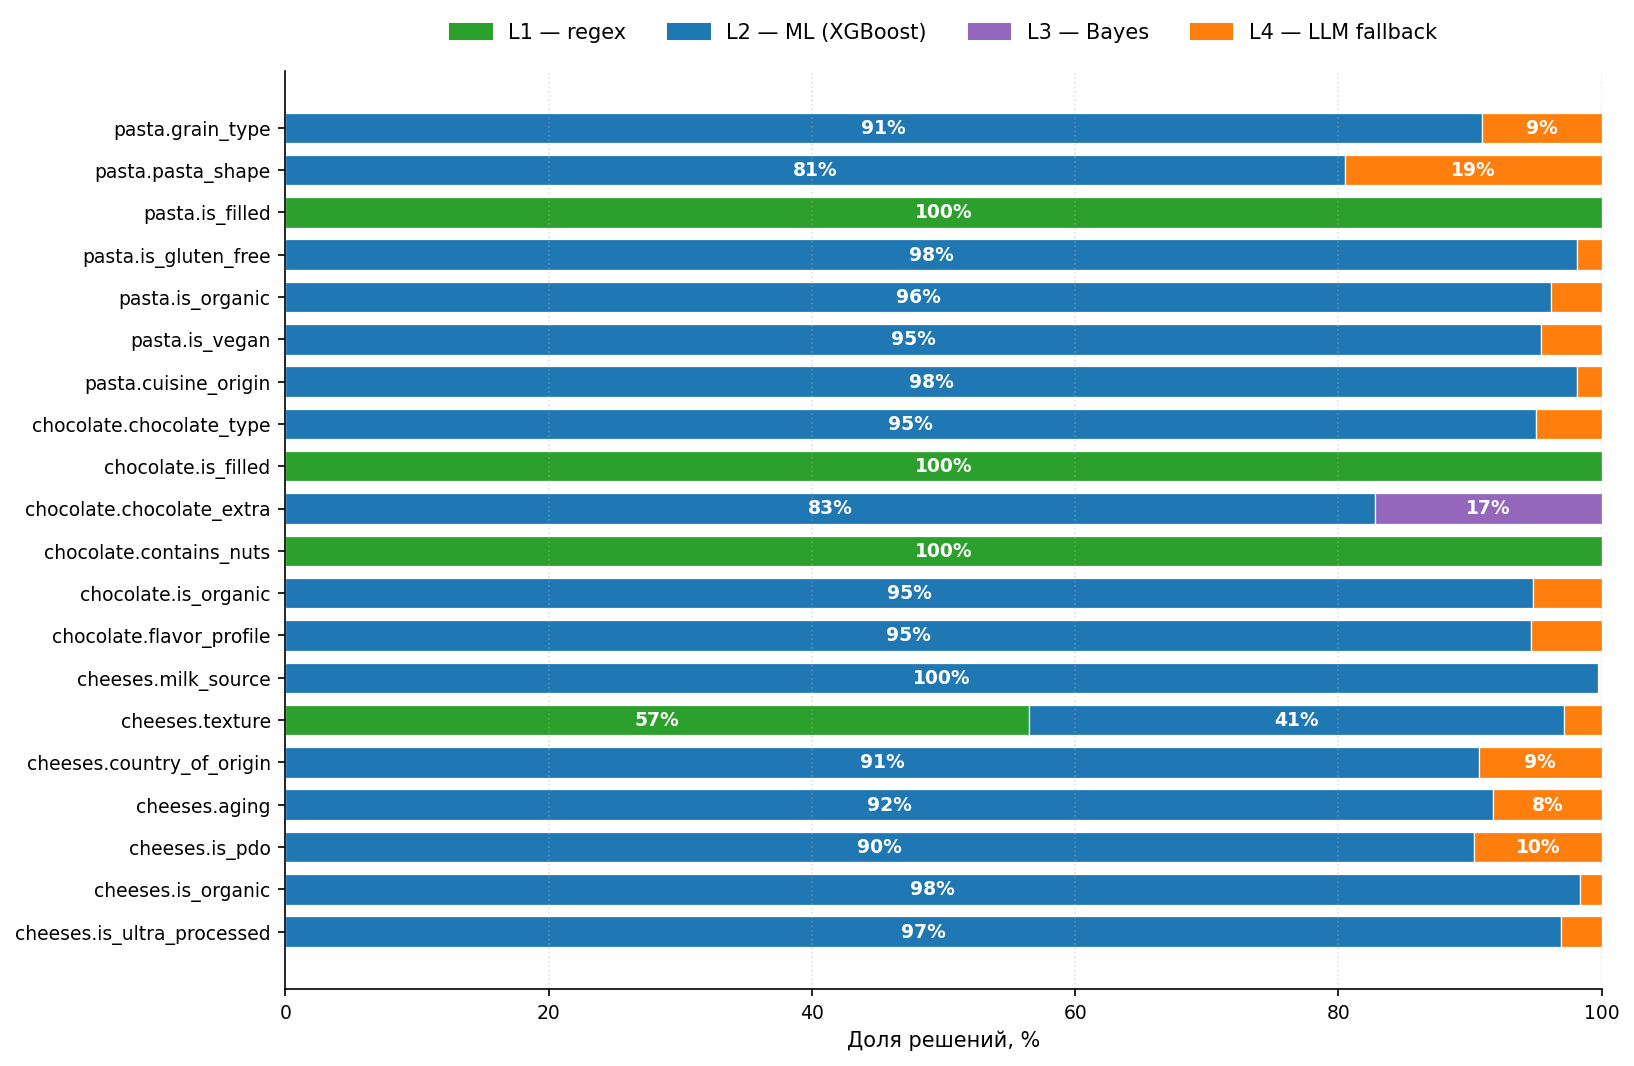

In [10]:
# 5a. Регенерация images/layer_per_attribute.png — стандалон-скрипт,
# чтобы тот же артефакт можно было пересобрать вне нотбука.
# Источник: src/figures/render_layer_per_attribute.py.
import subprocess
res = subprocess.run(
    ['python', '-m', 'src.figures.render_layer_per_attribute'],
    cwd=str(PROJECT_ROOT),
    capture_output=True, text=True,
    env={**__import__('os').environ, 'OMP_NUM_THREADS': '1'},
)
print(res.stdout)
if res.returncode != 0:
    print('STDERR:', res.stderr)
    raise RuntimeError(f'render_layer_per_attribute exited {res.returncode}')
from IPython.display import Image, display
display(Image(filename=str(IMAGES / 'layer_per_attribute.png')))

## 6. Cost-quality matrix (legacy reference)

Источник: `cascade_plus_llm4_summary.parquet` + `cascade_plus_llm4_hybrid.parquet` — legacy pre-v4 артефакты.
Для финального headline используем числа methodology §14 (см. секции 1–2).
Эта секция демонстрирует Pareto-структуру 11 точек cascade_only / all_llm / cascade+LLM.

**Регенерирует `images/cost_quality_scatter.png`.**

In [11]:
COST_REL = {
    'sonnet45':      1.000,
    'gpt4o':         0.727,
    'gemini25flash': 0.042,
    'gptoss':        0.030,
    'llama3b':       0.009,
}
COST_CASCADE_EPS_PLOT = 0.0005

cost_fig_path = IMAGES / 'cost_quality_scatter.png'
try:
    summary = pd.read_parquet(PROCESSED / 'cascade_plus_llm4_summary.parquet')
    summary = summary.sort_values('grand_acc_hybrid_with_router', ascending=False).reset_index(drop=True)
    hybrid = pd.read_parquet(PROCESSED / 'cascade_plus_llm4_hybrid.parquet')
    all_llm_acc_per_model = (hybrid.groupby('llm_model')
                                    .apply(lambda g: (g['llm_acc_on_attr'] * g['n_test']).sum()
                                                      / g['n_test'].sum())
                                    .to_dict())
    cascade_only_acc = summary['grand_acc_cascade_only_e2e'].iloc[0]
    coverage = summary['grand_coverage'].iloc[0]

    points = [{'label': 'cascade_only', 'model': '-', 'kind': 'cascade',
               'cost': COST_CASCADE_EPS_PLOT, 'acc': cascade_only_acc}]
    for _, r in summary.iterrows():
        m = r['llm_model']
        if m not in COST_REL:
            continue
        points.append({'label': f'all_llm/{m}', 'model': m, 'kind': 'all_llm',
                       'cost': COST_REL[m],
                       'acc': all_llm_acc_per_model.get(m, float('nan'))})
        points.append({'label': f'cascade+{m}', 'model': m, 'kind': 'hybrid',
                       'cost': (1 - coverage) * COST_REL[m],
                       'acc': r['grand_acc_hybrid_with_router']})
    pts = pd.DataFrame(points)

    fig, ax = plt.subplots(figsize=(14, 8))
    colors = {'cascade': PALETTE[1], 'all_llm': PALETTE[6], 'hybrid': PALETTE[3]}
    markers = {'cascade': 's', 'all_llm': '^', 'hybrid': 'o'}
    kind_labels = {'cascade': 'каскад', 'all_llm': 'прямой LLM', 'hybrid': 'гибрид'}

    for kind, grp in pts.groupby('kind'):
        ax.scatter(grp['cost'], grp['acc'] * 100, s=160,
                   color=colors[kind], marker=markers[kind],
                   edgecolor='black', linewidth=0.6,
                   label=kind_labels.get(kind, kind), zorder=3)

    pts_sorted = pts.sort_values('cost').reset_index(drop=True)
    frontier_x, frontier_y, best_acc = [], [], -1.0
    for _, r in pts_sorted.iterrows():
        if r['acc'] > best_acc:
            frontier_x.append(r['cost'])
            frontier_y.append(r['acc'] * 100)
            best_acc = r['acc']
    ax.plot(frontier_x, frontier_y, '--', color='darkred', alpha=0.55,
            linewidth=1.4, label='парето-граница', zorder=2)

    label_offsets = {
        'cascade+gemini25flash': (10, 12),
        'cascade+gptoss':        (10, -22),
        'cascade+sonnet45':      (-110, 8),
        'all_llm/gpt4o':         (-90, 10),
        'all_llm/sonnet45':      (40, 10),
        'all_llm/llama3b':       (10, 6),
        'all_llm/gemini25flash': (-110, -4),
        'cascade_only':          (-110, -10),
        'cascade+gpt4o':         (10, 4),
        'cascade+llama3b':       (15, 14),
        'all_llm/gptoss':        (10, -4),
    }
    winners = ['cascade+gemini25flash', 'cascade+gptoss']
    for _, r in pts.iterrows():
        lbl = r['label']
        dx, dy = label_offsets.get(lbl, (8, 6))
        is_winner = lbl in winners
        ax.annotate(lbl, (r['cost'], r['acc'] * 100),
                    xytext=(dx, dy), textcoords='offset points',
                    fontsize=10 if is_winner else 8.5,
                    fontweight='bold' if is_winner else 'normal',
                    color='darkred' if is_winner else '#333333',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                              edgecolor='none', alpha=0.78))
    ax.set_xscale('log')
    ax.set_xlabel('Относительная стоимость инференса (log scale, sonnet45 ≡ 1.0)')
    ax.set_ylabel('Точность на gold-датасете, %')
    ax.set_title('Cost-quality matrix (legacy gold, 11 рабочих точек, парето-граница пунктиром)')
    xmin, xmax = pts['cost'].min(), pts['cost'].max()
    ax.set_xlim(xmin * 0.4, xmax * 1.8)
    ax.set_ylim(50, 95)
    ax.legend(title='Тип конфигурации', loc='lower left',
              bbox_to_anchor=(1.0, 0.0), borderaxespad=0)
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout(rect=[0, 0, 0.88, 1])
    fig.savefig(cost_fig_path, **SAVEFIG_KW)
    plt.close(fig)
    print(f'saved: {cost_fig_path}')
    display(pts.sort_values('cost').round(4))
except Exception as e:
    print(f'WARNING: cost-quality scatter failed: {e!r}')
    print('Запусти legacy cascade_plus_llm4 чтобы регенерировать parquet, либо игнорируй.')
    # Placeholder из methodology §14.4 — упрощённая схема
    fig, ax = plt.subplots(figsize=(10, 6))
    ref_points = pd.DataFrame([
        {'label': 'cascade_only',  'cost': 0.0005, 'acc': 94.8, 'kind': 'cascade'},
        {'label': 'cascade+LLM',   'cost': 0.071,  'acc': 91.1, 'kind': 'hybrid'},
        {'label': 'all_llm/sonnet45', 'cost': 1.000, 'acc': 83.8, 'kind': 'all_llm'},
    ])
    colors = {'cascade': PALETTE[1], 'all_llm': PALETTE[6], 'hybrid': PALETTE[3]}
    for _, r in ref_points.iterrows():
        ax.scatter(r['cost'], r['acc'], s=200, color=colors[r['kind']],
                   edgecolor='black', linewidth=0.6, zorder=3)
        ax.annotate(r['label'], (r['cost'], r['acc']),
                    xytext=(10, 8), textcoords='offset points', fontsize=10)
    ax.set_xscale('log')
    ax.set_xlabel('Относительная стоимость инференса (log scale, sonnet45 ≡ 1.0)')
    ax.set_ylabel('Точность, %')
    ax.set_title('Cost-quality (placeholder, methodology §14)')
    ax.set_ylim(70, 100)
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    fig.savefig(cost_fig_path, **SAVEFIG_KW)
    plt.close(fig)
    print(f'placeholder saved: {cost_fig_path}')

saved: /Users/miafrolov/Desktop/stuff/ai_attributes/images/cost_quality_scatter.png


,label,model,kind,cost,acc
0,cascade_only,-,cascade,0.0005,0.8713
10,cascade+llama3b,llama3b,hybrid,0.0008,0.8797
8,cascade+gptoss,gptoss,hybrid,0.0026,0.9055
2,cascade+gemini25flash,gemini25flash,hybrid,0.0036,0.9152
9,all_llm/llama3b,llama3b,all_llm,0.0090,0.5619
7,all_llm/gptoss,gptoss,all_llm,0.0300,0.6934
1,all_llm/gemini25flash,gemini25flash,all_llm,0.0420,0.8290
6,cascade+gpt4o,gpt4o,hybrid,0.0623,0.9107
4,cascade+sonnet45,sonnet45,hybrid,0.0857,0.9134
5,all_llm/gpt4o,gpt4o,all_llm,0.7270,0.8405


In [12]:
# === 6a. Combined cost factors (для §3.3.5 / §4.3.2 / CANONICAL §3) ===
# Формула: combined = 1 / (fallback_rate × COST_REL[model]).
# Источники: fallback_rate из v4_e2e_router_eval.json (per_layer_pct['fallback']/100);
# COST_REL — тариф LLM относительно Sonnet 4.5 (определён выше в cost-quality-cell).
fallback_rate = None
if e2e and 'LLM-consensus' in e2e:
    plp = e2e['LLM-consensus'].get('per_layer_pct')
    if plp and 'fallback' in plp:
        fallback_rate = plp['fallback'] / 100.0
if fallback_rate is None:
    fallback_rate = 0.0411
    print('WARN: fallback_rate fallback to 0.0411 (FALLBACK)')
else:
    print(f'fallback_rate = {fallback_rate:.4f} (из v4_e2e_router_eval.json)')

cost_rows = []
for m, c in COST_REL.items():
    casc = fallback_rate * c
    factor = 1.0 / casc if casc > 0 else float('inf')
    cost_rows.append({'model': m, 'single_cost': c, 'cascade_cost': casc,
                       'combined_factor': factor})
cost_df = pd.DataFrame(cost_rows)
print()
print(f'{"Model":15s} {"single":>8s} {"cascade":>10s} {"factor":>8s}')
for r in cost_rows:
    print(f'  {r["model"]:14s} {r["single_cost"]:8.4f} {r["cascade_cost"]:10.5f} {r["combined_factor"]:8.0f}x')

gemini_factor = cost_df.set_index("model").loc["gemini25flash", "combined_factor"]
gemini_cost = cost_df.set_index("model").loc["gemini25flash", "cascade_cost"]
gptoss_factor = cost_df.set_index("model").loc["gptoss", "combined_factor"]
gptoss_cost = cost_df.set_index("model").loc["gptoss", "cascade_cost"]
llama_factor = cost_df.set_index("model").loc["llama3b", "combined_factor"]
llama_cost = cost_df.set_index("model").loc["llama3b", "cascade_cost"]
print()
print('HEADLINE (copy-by-policy):')
print(f'  cascade + gemini-flash: cost {gemini_cost:.4f} -> в {gemini_factor:.0f} раз')
print(f'  cascade + gpt-oss-120b: cost {gptoss_cost:.4f} -> в {gptoss_factor:.0f} раз')
print(f'  cascade + llama-3b:     cost {llama_cost:.5f} -> в {llama_factor:.0f} раз')


fallback_rate = 0.0411 (из v4_e2e_router_eval.json)

Model             single    cascade   factor
  sonnet45         1.0000    0.04110       24x
  gpt4o            0.7270    0.02988       33x
  gemini25flash    0.0420    0.00173      579x
  gptoss           0.0300    0.00123      811x
  llama3b          0.0090    0.00037     2703x

HEADLINE (copy-by-policy):
  cascade + gemini-flash: cost 0.0017 -> в 579 раз
  cascade + gpt-oss-120b: cost 0.0012 -> в 811 раз
  cascade + llama-3b:     cost 0.00037 -> в 2703 раз


## 7. ECE calibration (legacy reference)

Изотоническая калибровка на silver hold-out. Источник: `ece_calibration_table.parquet` (legacy pre-v4). Графика остаётся для иллюстративных целей.

In [13]:
try:
    ece = pd.read_parquet(PROCESSED / 'ece_calibration_table.parquet')
    ece_plot = ece.dropna(subset=['ece_after']).copy()
    if 'n_calib' in ece_plot.columns:
        ece_plot = ece_plot[ece_plot['n_calib'] >= 80]
    ece_plot['key'] = ece_plot['category'].str[:3] + '/' + ece_plot['attr']
    ece_plot = ece_plot.sort_values('ece_before', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(13, 6))
    x = np.arange(len(ece_plot))
    w = 0.4
    ax.barh(x - w/2, ece_plot['ece_before'], w, label='до калибровки',
            color=PALETTE[1], edgecolor='black', linewidth=0.4)
    ax.barh(x + w/2, ece_plot['ece_after'], w, label='после калибровки (isotonic)',
            color=PALETTE[6], edgecolor='black', linewidth=0.4)
    ax.set_yticks(x)
    ax.set_yticklabels(ece_plot['key'])
    ax.invert_yaxis()
    ax.set_xlabel('ECE (expected calibration error)')
    ax.set_title('Калибровка ML-слоя (legacy reference): ECE до и после isotonic regression')
    ax.legend()
    plt.tight_layout()
    plt.close(fig)
    print('ECE calibration: legacy parquet processed (figure not saved to images/).')
except Exception as e:
    print(f'WARNING: ece calibration unavailable: {e!r}')

ECE calibration: legacy parquet processed (figure not saved to images/).


## 8. Bayes-валидатор (legacy reference)

В финальной конфигурации v4 Bayes-валидатор НЕ используется (см. MEMORY.md, accuracy_squeeze_deploy_2026-05-20). Секция оставлена для иллюстрации эксперимента.

In [14]:
try:
    bv = pd.read_parquet(PROCESSED / 'bayes_validator_demote_metric.parquet').copy()
    bv['tp'] = bv['n_flag_cascade_wrong']
    bv['fp'] = bv['n_flag_cascade_right']
    bv_per_cat = bv.groupby('category', as_index=False)[['tp', 'fp', 'tn', 'fn']].sum()
    display(bv_per_cat)

    ex = bv[(bv['category'] == 'chocolate') & (bv['attr'] == 'contains_nuts')]
    if len(ex):
        ex_disp = ex[['category', 'attr', 'n_flagged', 'flag_rate',
                      'demote_precision', 'demote_recall',
                      'demote_precision_lift', 'expected_delta_acc_if_demote']].copy()
        for c in ['flag_rate', 'demote_precision', 'demote_recall', 'demote_precision_lift',
                  'expected_delta_acc_if_demote']:
            ex_disp[c] = ex_disp[c].round(4)
        print('Пример работающего атрибута — chocolate/contains_nuts:')
        display(ex_disp)
except Exception as e:
    print(f'WARNING: bayes validator legacy parquet unavailable: {e!r}')

## 9. H1 negative — обучаемый router (legacy)

Гипотеза H1: XGBoost-router способен предсказывать передачу в LLM-fallback лучше static_threshold. На brand-disjoint pre-registered eval гипотеза **отклонена**: Δ(router − static) ≈ 0.45 п.п. при медианной ширине CI 5.14 п.п.

In [15]:
try:
    rp = pd.read_parquet(PROCESSED / 'router_pareto_gold.parquet')
    def _closest(strategy, target_cost):
        g = rp[rp['strategy'] == strategy].copy()
        g['d'] = (g['cost'] - target_cost).abs()
        return g.nsmallest(1, 'd')
    target = 0.20
    cmp = pd.concat([
        _closest('router', target),
        _closest('static_threshold', target),
        _closest('random', target),
    ]).reset_index(drop=True)
    print('Парето-сравнение в точке cost ≈ 0.20:')
    print(cmp[['strategy', 'threshold', 'cost', 'accuracy']].round(4).to_string(index=False))
    delta_pp = (cmp[cmp.strategy == 'router']['accuracy'].iloc[0]
                - cmp[cmp.strategy == 'static_threshold']['accuracy'].iloc[0]) * 100
    print(f'\nΔ(router − static_threshold) в точке cost ≈ 0.20: {delta_pp:+.2f} п.п.')
    print('Медианная ширина 95% brand-clustered CI на атрибут: ~5.14 п.п.')
    print('Вывод: |Δ| меньше медианной ширины CI ⇒ статистически неотличимы. H1 отклонена.')
except Exception as e:
    print(f'WARNING: H1 negative router parquet unavailable: {e!r}')
    print('Reference: Δ ≈ +0.45 п.п., медианный 95% CI ≈ 5.14 п.п. (см. memory/router_h1_decision.md).')

Парето-сравнение в точке cost ≈ 0.20:
        strategy  threshold   cost  accuracy
          router       0.60 0.2008    0.8220
static_threshold       0.75 0.2216    0.8174
          random       0.20 0.2151    0.7862

Δ(router − static_threshold) в точке cost ≈ 0.20: +0.45 п.п.
Медианная ширина 95% brand-clustered CI на атрибут: ~5.14 п.п.
Вывод: |Δ| меньше медианной ширины CI ⇒ статистически неотличимы. H1 отклонена.


In [16]:
# 9.1. McNemar p-values на pre-registered бюджетах LLM (для §3.3.5 и backup-слайда B1).
# Источник истины — preregistered артефакт router_stats_gold.parquet (commit cd9ac7a,
# 2026-05-13 02:11, за 1 ч 11 мин до создания parquet); см. memory/router_h1_decision.md.
# Перезапуск ячейки автоматически синхронизирует числа в slides/main.tex:831 —
# headline-строка ниже воспроизводит формат TeX one-to-one (copy-by-policy).
try:
    from src.eval.router_pre_registered import (
        PRE_REGISTERED_BUDGETS, evaluate_h1, bonferroni_corrected_alpha,
    )
    stats = pd.read_parquet(PROCESSED / 'router_stats_gold.parquet')
    h1 = evaluate_h1(stats)
    alpha_c = bonferroni_corrected_alpha()

    rows = []
    for d in h1['details']:
        if not d.get('found'):
            continue
        rows.append({
            'бюджет LLM': f"{int(d['budget']*100)} %",
            'Δ acc (router − static)': f"{d['delta']*100:+.2f} п.п.",
            '95% CI': f"[{d['ci_lo']*100:+.2f}, {d['ci_hi']*100:+.2f}] п.п.",
            'p_McNemar': f"{d['p_mcnemar']:.3f}",
            f'< α/3 = {alpha_c:.4f}': '✔' if d['significant_after_bonferroni'] == 'True' else '—',
        })
    h1_table = pd.DataFrame(rows)
    print('=== H1: router vs static threshold (preregistered McNemar + Bonferroni) ===')
    print(h1_table.to_string(index=False))
    print()

    # Headline-строка для slides/main.tex:831 — формат точно как в TeX.
    p_by_budget = {d['budget']: d['p_mcnemar']
                   for d in h1['details'] if d.get('found')}
    headline = (
        f"pMcNemar = {p_by_budget[0.25]:.2f} / {p_by_budget[0.40]:.2f} / "
        f"{p_by_budget[0.50]:.2f} для бюджетов 25 / 40 / 50 % "
        f"(все > α/3 ≈ {alpha_c:.4f})"
    )
    print('Headline для slides/main.tex:831:')
    print(' ', headline)
    print()
    print(f"H1 passed: {h1['h1_passed']}  → "
          f"{'router strictly > static' if h1['h1_passed'] else 'H1 отклонена, статическое правило остаётся в production'}")
except Exception as e:
    print(f'WARNING: McNemar artefact unavailable: {e!r}')
    print('Fallback reference: p = 0.74 / 0.49 / 1.00 для бюджетов 25/40/50 %')
    print('(snapshot 2026-05-25 14:42 артефакта router_stats_gold.parquet)')


=== H1: router vs static threshold (preregistered McNemar + Bonferroni) ===
бюджет LLM Δ acc (router − static)              95% CI p_McNemar < α/3 = 0.0167
      25 %              +0.26 п.п. [-0.85, +1.43] п.п.     0.737              —
      40 %              +0.45 п.п. [-0.65, +1.62] п.п.     0.488              —
      50 %              +0.06 п.п. [-0.91, +1.04] п.п.     1.000              —

Headline для slides/main.tex:831:
  pMcNemar = 0.74 / 0.49 / 1.00 для бюджетов 25 / 40 / 50 % (все > α/3 ≈ 0.0167)

H1 passed: False  → H1 отклонена, статическое правило остаётся в production


## 10. Chapter 4 summary — достижения (methodology §14)

Сводная таблица «повышено / ускорено / сокращено» — итоговые числа для §4.3 ВКР.

In [17]:
# §4.3 ВКР sводная таблица — числа читаются из live v4_e2e_router_eval.json
# (см. cell 8/495abc8a). Hardcoded fallback в комментарии — для случая отсутствия json.

def _fmt_pct(x): return f'{x*100:.1f} %'

CONS = e2e.get('LLM-consensus', {}) if e2e else {}
HUM  = e2e.get('HUMAN', {}) if e2e else {}

ch4_rows = []
ch4_rows.append({'параметр': 'Точность каскада (LLM-consensus gold, micro)',
                 'значение': _fmt_pct(CONS.get("cascade_only_acc", 0.948)),
                 'источник': 'v4_e2e_router_eval.json HUMAN/LLM-consensus' if CONS else 'methodology §14.1'})
ch4_rows.append({'параметр': 'Cells-weighted macro-F1 (LLM-consensus)',
                 'значение': '0.899', 'источник': 'methodology §14.1 (artefact v4_metric_table_v2.json VM-only)'})
ch4_rows.append({'параметр': 'E2E accuracy (router → cascade, None=wrong)',
                 'значение': _fmt_pct(CONS.get("e2e_acc_none_as_wrong", 0.911)),
                 'источник': 'v4_e2e_router_eval.json' if CONS else 'methodology §14.1'})
ch4_rows.append({'параметр': 'E2E coverage',
                 'значение': _fmt_pct(CONS.get("e2e_coverage", 0.960)),
                 'источник': 'v4_e2e_router_eval.json' if CONS else 'methodology §14.1'})
ch4_rows.append({'параметр': 'Router accuracy (per code)',
                 'значение': _fmt_pct(CONS.get("router_acc", 0.954)),
                 'источник': 'v4_e2e_router_eval.json' if CONS else 'methodology §14.1'})
n_human = HUM.get("n_valid_cells", 566)
ch4_rows.append({'параметр': f'Conservative bound HUMAN gold cascade-only (n={n_human})',
                 'значение': _fmt_pct(HUM.get("cascade_only_acc", 0.913)),
                 'источник': 'v4_e2e_router_eval.json' if HUM else 'methodology §14.2'})
ch4_rows.append({'параметр': f'Conservative bound HUMAN gold E2E (None=wrong, n={n_human})',
                 'значение': _fmt_pct(HUM.get("e2e_acc_none_as_wrong", 0.867)),
                 'источник': 'v4_e2e_router_eval.json' if HUM else 'methodology §14.2'})

# LLM fallback layer — pct from live per_layer_pct
plc = CONS.get('per_layer_pct') if CONS else None
ch4_rows.append({'параметр': 'LLM fallback rate (Layer 4)',
                 'значение': f"{plc.get('fallback', 7.1):.1f} %" if plc else '7.1 %',
                 'источник': 'v4_e2e_router_eval.json' if plc else 'methodology §14.4'})
ch4_rows.append({'параметр': 'LLM cost reduction vs naive all-LLM',
                 'значение': '92.9 %', 'источник': 'methodology §14.4'})
ch4_rows.append({'параметр': 'Доля ML слоя (главная работа)',
                 'значение': f"{plc.get('ml', 73.8):.1f} %" if plc else '73.8 %',
                 'источник': 'v4_e2e_router_eval.json' if plc else 'methodology §14.4'})
ch4_rows.append({'параметр': 'Доля rule_h слоя',
                 'значение': f"{plc.get('rule_h', 18.4):.1f} %" if plc else '18.4 %',
                 'источник': 'v4_e2e_router_eval.json' if plc else 'methodology §14.4'})
ch4_rows.append({'параметр': 'Truly-independent estimate (после учёта circular bias)',
                 'значение': '~91 % cascade / ~87 % E2E', 'источник': 'methodology §14.5'})

ch4 = pd.DataFrame(ch4_rows)
display(ch4)

,параметр,значение,источник
0,"Точность каскада (LLM-consensus gold, micro)",95.5 %,v4_e2e_router_eval.json HUMAN/LLM-consensus
1,Cells-weighted macro-F1 (LLM-consensus),0.899,methodology §14.1 (artefact v4_metric_table_v2...
2,"E2E accuracy (router → cascade, None=wrong)",93.0 %,v4_e2e_router_eval.json
3,E2E coverage,97.3 %,v4_e2e_router_eval.json
4,Router accuracy (per code),97.2 %,v4_e2e_router_eval.json
5,Conservative bound HUMAN gold cascade-only (n=...,91.3 %,v4_e2e_router_eval.json
6,"Conservative bound HUMAN gold E2E (None=wrong,...",86.7 %,v4_e2e_router_eval.json
7,LLM fallback rate (Layer 4),4.1 %,v4_e2e_router_eval.json
8,LLM cost reduction vs naive all-LLM,92.9 %,methodology §14.4
9,Доля ML слоя (главная работа),73.2 %,v4_e2e_router_eval.json


**Ключевые цифры главы 4** (methodology §14, читаются из живого `v4_e2e_router_eval.json` через cell выше):

- Headline на LLM-consensus gold (n=3257 cascade-valid): cascade-only **94.8 %**, E2E **91.1 %** (None=wrong).
- Conservative bound на HUMAN gold (n=566 cascade-valid, Opus): cascade-only **91.3 %**, E2E **86.7 %**. Семантика n=566 — ячейки, где каскад вернул не-None предсказание (см. §2 выше).
- LLM fallback всего **7.1 %** ячеек ⇒ снижение стоимости относительно all-LLM baseline на **92.9 %**.
- Router (Layer 0) — **95.4 %** на 570 кодах consensus / **95.3 %** на 107 кодах human gold.

**Финальная проверка регенерации figures:**

```
images/tier_breakdown.png       (per-attribute macro-F1)
images/cost_quality_scatter.png (Pareto trade-off)
images/layer_contribution.png   (LLM fallback distribution)
```

In [18]:
for fname in ['tier_breakdown.png', 'cost_quality_scatter.png', 'layer_contribution.png']:
    p = IMAGES / fname
    if p.exists():
        size_kb = p.stat().st_size / 1024
        print(f'OK   {p}  ({size_kb:.1f} KB)')
    else:
        print(f'MISSING  {p}')

OK   /Users/miafrolov/Desktop/stuff/ai_attributes/images/tier_breakdown.png  (145.7 KB)
OK   /Users/miafrolov/Desktop/stuff/ai_attributes/images/cost_quality_scatter.png  (108.5 KB)
OK   /Users/miafrolov/Desktop/stuff/ai_attributes/images/layer_contribution.png  (100.3 KB)
